In [56]:
import random
from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import networkit as nk
import networkx as nx
import numpy as np
from networkit.embedding import Node2Vec
from sklearn.metrics import f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
nk.engineering.setNumberOfThreads(1)

## Networkit documentation
https://networkit.github.io/dev-docs/python_api/modules.html

## Loading network

In [57]:
data_path = Path('./citeseer/citeseer.adjlist')

nx_G = nx.read_adjlist(data_path, nodetype=int)
G = nk.nxadapter.nx2nk(nx_G)

In [58]:
import time

# --- Betweenness Centrality ---
start = time.time()
nx_bc = nx.betweenness_centrality(nx_G)
nx_bc_time = time.time() - start

start = time.time()
nk_bc = nk.centrality.Betweenness(G)
nk_bc.run()
nk_bc_time = time.time() - start

print(f"Betweenness Centrality:")
print(f"  NetworkX:  {nx_bc_time:.4f}s")
print(f"  NetworKit: {nk_bc_time:.4f}s")
print(f"  Przyspieszenie: {nx_bc_time / nk_bc_time:.1f}x")

Betweenness Centrality:
  NetworkX:  24.0002s
  NetworKit: 2.0720s
  Przyspieszenie: 11.6x


In [59]:
# --- Connected Components ---
start = time.time()
nx_cc = nx.number_connected_components(nx_G)
nx_cc_time = time.time() - start

start = time.time()
nk_cc = nk.components.ConnectedComponents(G)
nk_cc.run()
nk_cc_time = time.time() - start

print(f"Connected Components:")
print(f"  NetworkX:  {nx_cc_time:.6f}s  ({nx_cc} komponentów)")
print(f"  NetworKit: {nk_cc_time:.6f}s  ({nk_cc.numberOfComponents()} komponentów)")
print(f"  Przyspieszenie: {nx_cc_time / nk_cc_time:.1f}x")

Connected Components:
  NetworkX:  0.006508s  (438 komponentów)
  NetworKit: 0.000283s  (438 komponentów)
  Przyspieszenie: 23.0x


In [60]:
# Overview — podstawowe statystyki sieci
nk.overview(G)

# Degree centrality
dc = nk.centrality.DegreeCentrality(G)
dc.run()

# PageRank
pr = nk.centrality.PageRank(G)
pr.run()

# Closeness centrality
cc = nk.centrality.Closeness(G, False, nk.centrality.ClosenessVariant.Generalized)
cc.run()

# Top 5 węzłów dla każdej miary
print("Top 5 — Degree Centrality:")
for node, score in dc.ranking()[:5]:
    print(f"  węzeł {node}: {score:.4f}")

print("\nTop 5 — PageRank:")
for node, score in pr.ranking()[:5]:
    print(f"  węzeł {node}: {score:.4f}")

print("\nTop 5 — Closeness Centrality:")
for node, score in cc.ranking()[:5]:
    print(f"  węzeł {node}: {score:.4f}")

Network Properties:
nodes, edges			3327, 4552
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000823
clustering coefficient		0.141471
min/max/avg degree		0, 99, 2.736399
degree assortativity		0.142213
number of connected components	438
size of largest component	2120 (63.72 %)
Top 5 — Degree Centrality:
  węzeł 60: 99.0000
  węzeł 74: 51.0000
  węzeł 198: 35.0000
  węzeł 109: 34.0000
  węzeł 105: 30.0000

Top 5 — PageRank:
  węzeł 60: 0.0053
  węzeł 74: 0.0043
  węzeł 137: 0.0018
  węzeł 242: 0.0017
  węzeł 416: 0.0016

Top 5 — Closeness Centrality:
  węzeł 129: 0.1039
  węzeł 536: 0.1027
  węzeł 491: 0.1021
  węzeł 481: 0.1018
  węzeł 230: 0.1013


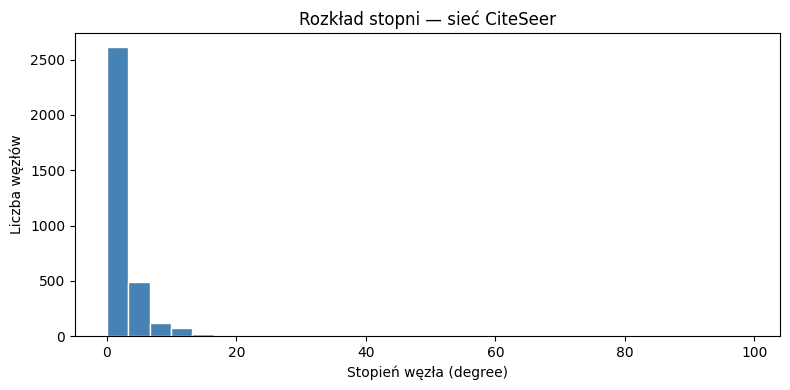

Średni stopień: 2.74
Maksymalny stopień: 99
Mediana stopnia: 2.0


In [61]:
degrees = [G.degree(v) for v in G.iterNodes()]

plt.figure(figsize=(8, 4))
plt.hist(degrees, bins=30, color='steelblue', edgecolor='white')
plt.xlabel("Stopień węzła (degree)")
plt.ylabel("Liczba węzłów")
plt.title("Rozkład stopni — sieć CiteSeer")
plt.tight_layout()
plt.show()

print(f"Średni stopień: {np.mean(degrees):.2f}")
print(f"Maksymalny stopień: {np.max(degrees)}")
print(f"Mediana stopnia: {np.median(degrees):.1f}")

## Sparsification

sparsyfikacja jest jednym z typów redukcji grafu, która wybiera istotne węzły i krawędzie, odrzucając pozostałe. W trakcie działania procesu dla danego grafu $G = (A, X)$,  model sparsyfikacji grafu wybiera istniejące węzły lub krawędzie z grafu $G$, tworząc $G' = (A', X')$. Innymi słowy, elementy $A'$ lub $X'$ są podzbiorem elementów w $A$ lub $X$.

In [62]:
edge_ratio = 0.25

G.indexEdges()
sparsifier_random = nk.sparsification.RandomEdgeSparsifier()
sparseG_random = sparsifier_random.getSparsifiedGraphOfSize(G, edge_ratio)

print(f"Oryginał    — węzły: {G.numberOfNodes()}, krawędzie: {G.numberOfEdges()}")
print(f"Zredukowany — węzły: {sparseG_random.numberOfNodes()}, krawędzie: {sparseG_random.numberOfEdges()}")

Oryginał    — węzły: 3327, krawędzie: 4552
Zredukowany — węzły: 3327, krawędzie: 1146


Network Properties:
nodes, edges			3327, 1146
directed?			False
weighted?			False
isolated nodes			1827
self-loops			0
density				0.000207
clustering coefficient		0.008684
min/max/avg degree		0, 23, 0.688909
degree assortativity		0.143743
number of connected components	2253
size of largest component	241 (7.24 %)


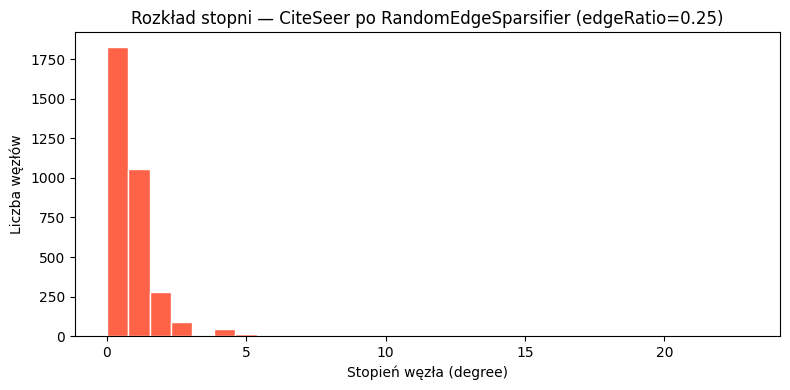

In [63]:
nk.overview(sparseG_random)

degrees_sparse = [sparseG_random.degree(v) for v in sparseG_random.iterNodes()]

plt.figure(figsize=(8, 4))
plt.hist(degrees_sparse, bins=30, color='tomato', edgecolor='white')
plt.xlabel("Stopień węzła (degree)")
plt.ylabel("Liczba węzłów")
plt.title(f"Rozkład stopni — CiteSeer po RandomEdgeSparsifier (edgeRatio={edge_ratio})")
plt.tight_layout()
plt.show()

LocalDegreeSparsifier — węzły: 3327, krawędzie: 2817
Network Properties:
nodes, edges			3327, 2817
directed?			False
weighted?			False
isolated nodes			48
self-loops			0
density				0.000509
clustering coefficient		0.000000
min/max/avg degree		0, 99, 1.693417
degree assortativity		-0.032334
number of connected components	510
size of largest component	634 (19.06 %)


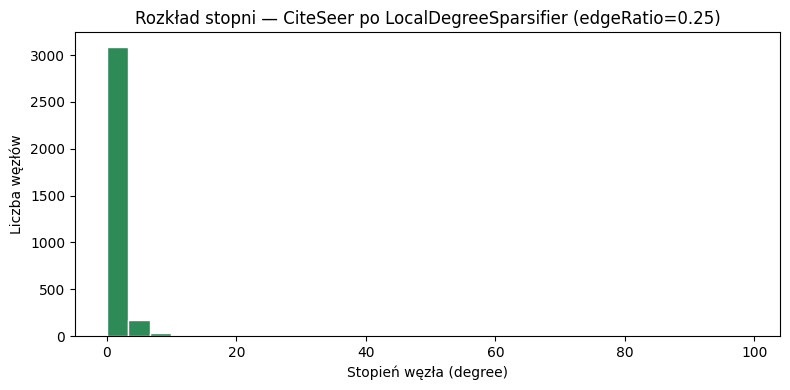

In [64]:
sparsifier_local = nk.sparsification.LocalDegreeSparsifier()
sparseG_local = sparsifier_local.getSparsifiedGraphOfSize(G, edge_ratio)

print(f"LocalDegreeSparsifier — węzły: {sparseG_local.numberOfNodes()}, krawędzie: {sparseG_local.numberOfEdges()}")
nk.overview(sparseG_local)

degrees_local = [sparseG_local.degree(v) for v in sparseG_local.iterNodes()]

plt.figure(figsize=(8, 4))
plt.hist(degrees_local, bins=30, color='seagreen', edgecolor='white')
plt.xlabel("Stopień węzła (degree)")
plt.ylabel("Liczba węzłów")
plt.title(f"Rozkład stopni — CiteSeer po LocalDegreeSparsifier (edgeRatio={edge_ratio})")
plt.tight_layout()
plt.show()

In [65]:
ratios = [0.1, 0.25, 0.5, 0.75, 0.9]

print(f"{'edgeRatio':<12} {'Krawędzie':<12} {'Komponenty':<12} {'Śr. stopień'}")
for r in ratios:
    g = nk.sparsification.RandomEdgeSparsifier().getSparsifiedGraphOfSize(G, r)
    cc = nk.components.ConnectedComponents(g)
    cc.run()
    avg_deg = sum(g.degree(v) for v in g.iterNodes()) / g.numberOfNodes()
    print(f"{r:<12} {g.numberOfEdges():<12} {cc.numberOfComponents():<12} {avg_deg:.2f}")

edgeRatio    Krawędzie    Komponenty   Śr. stopień
0.1          454          2874         0.27
0.25         1124         2284         0.68
0.5          2261         1425         1.36
0.75         3398         878          2.04
0.9          4090         593          2.46


## Link prediction

celem zadania jest przewidywanie,
czy pomiędzy daną parą węzłów powinna istnieć krawędź.
Problem ten jest formułowany jako zadanie klasyfikacji binarnej,
gdzie:
- klasa pozytywna odpowiada istniejącym krawędziom,
- klasa negatywna odpowiada parom węzłów bez połączenia.

W naszym przypadku celem modelu jest odtworzenie struktury
zredukowanego grafu na podstawie dostępnych danych.

### Negative sampling

proces polegający na losowaniu par węzłów,
które **nie są połączone krawędzią** w grafie.

Jest to kluczowy krok w zadaniu link prediction, ponieważ:
- graf nie zawiera jawnych przykładów negatywnych,
- model klasyfikacyjny wymaga danych obu klas,
- losowanie negatywnych krawędzi umożliwia zbalansowanie zbioru danych.

### Cechy krawędzi (edge features)

w tym ćwiczeniu cechy krawędzi są budowane na podstawie
**embeddingów węzłów uzyskanych metodą Node2Vec**.

Dla każdej krawędzi (u, v):
- pobierane są embeddingi węzłów u i v,
- łączone są w jeden wektor cech.


In [66]:
def sample_negative_edges(
    G: nk.Graph,
    num_samples: int,
    forbidden_edges: set[tuple[int, int]] | None = None,
) -> np.ndarray:
    """
    Funkcja powinna losować "negatywne krawędzie" w grafie, czyli takie, które nie istnieją w grafie G.

    Parametry
    G : nk.Graph
        Graf wejściowy
    num_samples : int
        Liczba negatywnych krawędzi do wylosowania
    forbidden_edges : set[tuple[int,int]] lub None
        Zbiór krawędzi, których NIE można wylosować (np. istniejących w grafie)

    Wskazówki:
    - Pomiń pętle (u==v)
    - Normalizuj pary dla grafu nieskierowanego (u<=v)
    - Pomijaj krawędzie istniejące i zakazane
    - Wylosowane krawędzie mogą być zwracane w formie np. numpy array
    """
    if forbidden_edges is None:
        forbidden_edges = set()

    # Zbiór istniejących krawędzi w grafie (znormalizowane)
    existing_edges = set((min(u, v), max(u, v)) for u, v in G.iterEdges())
    forbidden_normalized = set((min(u, v), max(u, v)) for u, v in forbidden_edges)
    all_forbidden = existing_edges | forbidden_normalized

    nodes = list(G.iterNodes())
    n = len(nodes)
    negative_edges = []

    while len(negative_edges) < num_samples:
        u = random.choice(nodes)
        v = random.choice(nodes)

        # Pomiń pętle
        if u == v:
            continue

        # Normalizuj parę dla grafu nieskierowanego
        edge = (min(u, v), max(u, v))

        # Pomijaj krawędzie istniejące i zakazane
        if edge in all_forbidden:
            continue

        all_forbidden.add(edge)
        negative_edges.append(edge)

    return np.array(negative_edges)


def get_edge_features(
    edge_list: Iterable[tuple[int, int]],
    emb: np.ndarray,
) -> np.ndarray:
    """
    Funkcja ma tworzyć wektory cech dla krawędzi na podstawie embeddingów węzłów.

    Parametry
    edge_list : Iterable[tuple[int,int]]
        Lista krawędzi, np. [(u1,v1), (u2,v2), ...]
    emb : np.ndarray, shape=(n_nodes, embedding_dim)
        Macierz embeddingów węzłów (np. wynik Node2Vec)

    Output
    np.ndarray, shape=(len(edge_list), embedding_dim)
        Każdy wiersz to wektor cech krawędzi, np. iloczyn Hadamarda
        wektorów węzłów u i v

    Wskazówki:
    - Dla każdej krawędzi (u,v) pobierz emb[u] i emb[v]
    - Połącz je w jedną cechę (np. iloczyn Hadamarda)
    - Zbierz wszystkie krawędzie w jedną tablicę numpy
    """
    features = []
    for u, v in edge_list:
        # Iloczyn Hadamarda — mnożenie element po elemencie
        edge_feat = emb[u] * emb[v]
        features.append(edge_feat)

    return np.array(features)


def preprocess_graph(G: nk.Graph) -> tuple[nk.Graph, dict]:
    """
    Przygotuj graf do Node2Vec

    Wskazówki:
    1. Konwertuj NetworKit -> NetworkX
    2. Usuń izolowane węzły
    3. Przypisz węzłom nowe ID 0..n-1
    4. Konwertuj z powrotem NetworkX -> NetworKit
    """
    # 1. Konwertuj NetworKit -> NetworkX
    nx_g = nk.nxadapter.nk2nx(G)

    # 2. Usuń izolowane węzły
    isolated = list(nx.isolates(nx_g))
    nx_g.remove_nodes_from(isolated)

    # 3. Przypisz węzłom nowe ID 0..n-1 — zwróć też mapowanie
    sorted_nodes = sorted(nx_g.nodes())
    mapping = {old: new for new, old in enumerate(sorted_nodes)}
    nx_g = nx.relabel_nodes(nx_g, mapping)

    # 4. Konwertuj z powrotem NetworkX -> NetworKit
    return nk.nxadapter.nx2nk(nx_g), mapping

In [67]:
reduced_data_path = Path('./citeseer/0_9_citeseer.adjlist')
nx_reduced = nx.read_adjlist(reduced_data_path, nodetype=int)

In [68]:
# Buduj mapping bezpośrednio z nx_G (citeseer ID -> 0..n-1), pomijając
# round-trip przez NetworKit, który gubi oryginalne ID.
nx_G_clean = nx_G.copy()
nx_G_clean.remove_nodes_from(list(nx.isolates(nx_G_clean)))
mapping = {old: new for new, old in enumerate(sorted(nx_G_clean.nodes()))}

nx_G_mapped = nx.relabel_nodes(nx_G_clean, mapping)
nx_reduced_mapped = nx_reduced.subgraph([n for n in nx_reduced.nodes() if n in mapping]).copy()
nx_reduced_mapped = nx.relabel_nodes(nx_reduced_mapped, mapping)

# Buduj nk.Graph ręcznie, żeby ID na pewno były 0..n-1 (nx2nk może je przetasować).
def nx_to_nk_keep_ids(nx_g: nx.Graph, n: int) -> nk.Graph:
    nk_g = nk.Graph(n, weighted=False, directed=False)
    for u, v in nx_g.edges():
        nk_g.addEdge(u, v)
    return nk_g

n = len(mapping)
preprocessed_G         = nx_to_nk_keep_ids(nx_G_mapped, n)
preprocessed_reduced_G = nx_to_nk_keep_ids(nx_reduced_mapped, n)

orig_edges_set    = {(min(u, v), max(u, v)) for u, v in nx_G_mapped.edges()}
reduced_edges_set = {(min(u, v), max(u, v)) for u, v in nx_reduced_mapped.edges()}

removed_edges = list(orig_edges_set - reduced_edges_set)
orig_edges    = list(orig_edges_set)
reduced_edges = list(reduced_edges_set)

print("Original edges:", len(orig_edges))
print("Reduced edges:", len(reduced_edges))
print("Removed edges (to predict):", len(removed_edges))

Original edges: 4552
Reduced edges: 4094
Removed edges (to predict): 458


In [69]:
# preprocessed_G = preprocess_graph(G)
# preprocessed_reduced_G  = preprocess_graph(reduced_G)

# orig_edges = list(preprocessed_G.iterEdges())
# reduced_edges = list(preprocessed_reduced_G.iterEdges())

# removed_edges = list(set(orig_edges) - set(reduced_edges))

# print("Original edges:", len(orig_edges))
# print("Reduced edges:", len(reduced_edges))
# print("Removed edges (to predict):", len(removed_edges))

### Node2Vec
model uczenia reprezentacji węzłów w grafach, która odwzorowuje węzły na wektory w przestrzeni ciągłej, zachowując strukturę sieci. Kluczowym elementem node2vec jest *random walk*. Formalnie, dla danego węzła źródłowego $u$ symulujemy random walk o stałej długości $l$. Niech $c_i$ oznacza i‑ty węzeł w ścieżce, zaczynając od $c_0 = u$. Węzły $c_i$ są generowane zgodnie z rozkładem:

$$
P(c_i = x \mid c_{i-1} = v) = 
\begin{cases}
\frac{\pi_{v x}}{Z}, & \text{if} (v,x) \in E, \\
0, & \text{otherwise},
\end{cases}
$$

gdzie \($\pi_{v x}$\) to nienormalizowane prawdopodobieństwo przejścia między węzłami $v$ i $x$, a \($Z$\) jest stałą normalizującą.

Networkit documentation: https://networkit.github.io/dev-docs/python_api/embedding.html


In [70]:
node2vec = Node2Vec(
    G=preprocessed_reduced_G,
    P=1,    # bez preferencji powrotu
    Q=2,    # preferuj BFS — lokalna struktura sieci, dobra dla link prediction
    L=80,   # standardowa długość walku
    N=10,   # 10 walków na węzeł
    D=64,   # wymiar embeddingu
)
node2vec.run()
emb_matrix = np.array(node2vec.getFeatures())
print("Embeddings shape:", emb_matrix.shape)

Embeddings shape: (3279, 64)


### Budowa zbioru treningowego

W tym zdaniu zbiór treningowy jest budowany poprzez łączenie
próbek pozytywnych i negatywnych.

W kodzie:
- `sample_negative_edges` - wykorzystujemy do losowania par węzłów,
    pomiędzy którymi nie istnieje krawędź w grafie.
- `edge_features`
- `np.vstack` łączy macierze cech:
  - wiersze odpowiadają poszczególnym krawędziom,
  - najpierw krawędzie istniejące, potem negatywne,
- `np.hstack` łączy wektory etykiet:
  - `1` dla krawędzi istniejących,
  - `0` dla krawędzi negatywnych.

Ten sam proces jest wykorzystywny dla sieci powstałej po redukcji służącej jako zbiór treningowej oraz elementom sieci usuniętym w trakcie redukcji służącej jako zbiór testowy.

In [71]:
forbidden = set(orig_edges)
neg_edges = sample_negative_edges(preprocessed_reduced_G, len(reduced_edges), forbidden_edges=forbidden)

X_train = np.vstack([get_edge_features(reduced_edges, emb_matrix),
                     get_edge_features(neg_edges, emb_matrix)])
y_train = np.hstack([np.ones(len(reduced_edges)), np.zeros(len(neg_edges))])

neg_test = sample_negative_edges(preprocessed_reduced_G, len(removed_edges), forbidden_edges=forbidden)
X_test = np.vstack([get_edge_features(removed_edges, emb_matrix),
                    get_edge_features(neg_test, emb_matrix)])
y_test = np.hstack([np.ones(len(removed_edges)), np.zeros(len(neg_test))])

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

In [73]:
print("Test F1:", f1_score(y_test, y_pred, average='macro'))

Test F1: 0.7342495569010056
